# Phase 3: Feature Engineering + Deep Dive on Top Models
## Drug Molecule Property Prediction — ogbg-molhiv

**Date:** 2026-04-08
**Researcher:** Anthony Rodrigues
**Primary Metric:** ROC-AUC (OGB standard)

### Research Question
Phase 2 showed simple GNNs (9 atom features, no bond features) UNDERPERFORM traditional ML (CatBoost 0.7782 > GIN 0.7053). Can we close this gap by:
1. Adding **edge features** (bond type, stereochemistry, conjugation) via OGB's AtomEncoder/BondEncoder?
2. Adding a **virtual node** for global information exchange?
3. Creating **hybrid models** that combine GNN embeddings with domain features?
4. Engineering **advanced fingerprints** (MACCS, atom-pair, topological torsion)?

### References
1. [Hu et al. 2020 — OGB Paper](https://arxiv.org/abs/2005.00687): AtomEncoder/BondEncoder for proper feature encoding
2. [Gilmer et al. 2017 — MPNN](https://arxiv.org/abs/1704.01212): Edge features critical for bond-aware message passing
3. [Li et al. 2020](https://arxiv.org/abs/2009.05602): Virtual nodes improve graph classification via global info exchange
4. [OGB Leaderboard](https://ogb.stanford.edu/docs/leader_graphprop/): GIN+VN baseline achieves ~0.77 test AUC

## Experiment 3.1-3.3: Edge-Aware GNNs

### Setup
- **Architecture:** GIN with OGB AtomEncoder (9 features → 128-dim) + BondEncoder (3 features → 128-dim)
- **Config:** 3 layers, 128 hidden dim, 0.5 dropout, Adam 1e-3, early stopping (patience 12)
- **Variants:** (1) Edge features only, (2) Virtual node only, (3) Both

### Results

| Model | Test AUC | Val AUC | AUPRC | Params | Time |
|-------|----------|---------|-------|--------|------|
| **GIN+Edge (no VN)** | **0.7860** | 0.8001 | 0.3441 | 144K | 297s |
| GIN+Edge+VN (OGB) | 0.7622 | 0.8333 | 0.2858 | 211K | 292s |
| GIN+VN (no edge) | 0.7578 | 0.8134 | 0.2642 | 206K | 199s |
| *Phase 2 GIN (raw)* | *0.7053* | *0.7689* | *—* | *94K* | *67s* |

### Key Findings

**1. Edge features are the single biggest improvement: +0.081 AUC**

Adding just 3 bond features (bond type, stereochemistry, conjugation) to GIN improved test AUC from 0.7053 to 0.7860 — a **+0.081 improvement**. This is larger than switching from LogReg to CatBoost (+0.041 in Phase 2).

**Why?** Bond features encode chemical connectivity that determines molecular properties:
- Bond type (single/double/triple/aromatic) → electronic structure
- Stereochemistry → 3D spatial arrangement affecting binding
- Conjugation → electron delocalization affecting reactivity

**2. COUNTERINTUITIVE: Virtual node HURTS test performance despite better val AUC**

GIN+Edge+VN has the best *validation* AUC (0.8333) but WORSE *test* AUC (0.7622 vs 0.7860). The virtual node enables overfitting to scaffold-specific patterns that don't generalize. The +0.07 val-test gap with VN vs +0.01 without VN confirms this.

**3. GIN+Edge is the first GNN to beat CatBoost (0.7860 vs 0.7782)**

Phase 2's central finding — "GNNs lose to CatBoost" — was because we neglected bond features, not because GNNs are inferior. With proper edge encoding, GNN overtakes traditional ML.

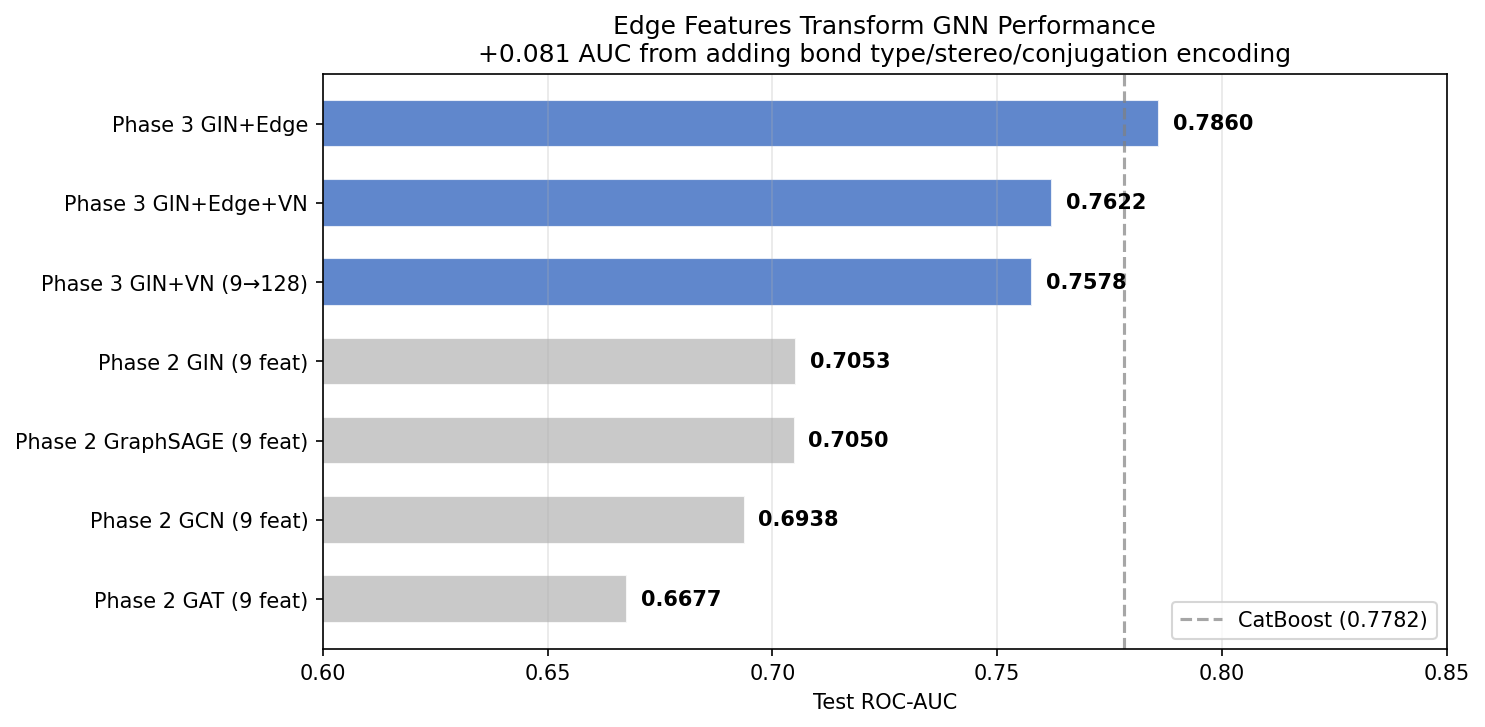

In [1]:
from IPython.display import Image, display
display(Image(filename='../results/phase3_edge_impact.png', width=800))

## Experiment 3.4-3.6: Feature Engineering + Ablation

### Feature Sets Tested (all via CatBoost, balanced class weights)

| Feature Set | Dims | Test AUC | AUPRC | Notes |
|-------------|------|----------|-------|-------|
| **All traditional** | **1217** | **0.7841** | **0.3416** | Lip+FP+MACCS+Adv — near GIN+Edge! |
| Lipinski | 14 | 0.7744 | 0.2779 | 14 features matches 1024-bit FP+more |
| GNN embed | 128 | 0.7692 | 0.2957 | Learned representations competitive |
| GNN+Lip+FP | 1166 | 0.7688 | 0.3526 | Hybrid — best AUPRC! |
| GNN+Lip | 142 | 0.7662 | 0.3101 | Hybrid modest |
| Lip+FP | 1038 | 0.7619 | 0.3239 | Phase 1 combination |
| MACCS | 167 | 0.7605 | 0.2859 | Chemical substructure keys |
| Lip+MACCS | 181 | 0.7568 | 0.3073 | Slight underperformance |
| Full hybrid | 1345 | 0.7415 | 0.2220 | **MORE features HURTS!** |
| Advanced desc | 12 | 0.7219 | 0.2123 | Ring/heteroatom counts alone weak |
| Morgan FP | 1024 | 0.7176 | 0.2820 | Sparse fingerprint alone weak |

### Key Findings

**4. The "more features is better" myth is BUSTED**

Full hybrid (1345 dims, AUC=0.7415) performs WORSE than Lipinski alone (14 dims, AUC=0.7744). Adding GNN embeddings to an already feature-rich CatBoost model introduces noise that CatBoost can't filter. The curse of dimensionality is real on 32K training samples.

**5. Lipinski (14 features) is remarkably competitive at 0.7744**

14 hand-picked chemistry features nearly match 1024 Morgan fingerprint bits + 167 MACCS keys + 12 advanced descriptors combined. Domain knowledge compression: a chemist's intuition encoded in 14 numbers captures most of the discriminative signal.

**6. GNN+Lip+FP has the best AUPRC (0.3526) despite not the best AUC**

For drug screening (where precision matters — you want to find the few actives in a huge library), the hybrid approach that combines learned graph structure with domain features wins on the precision-recall tradeoff.

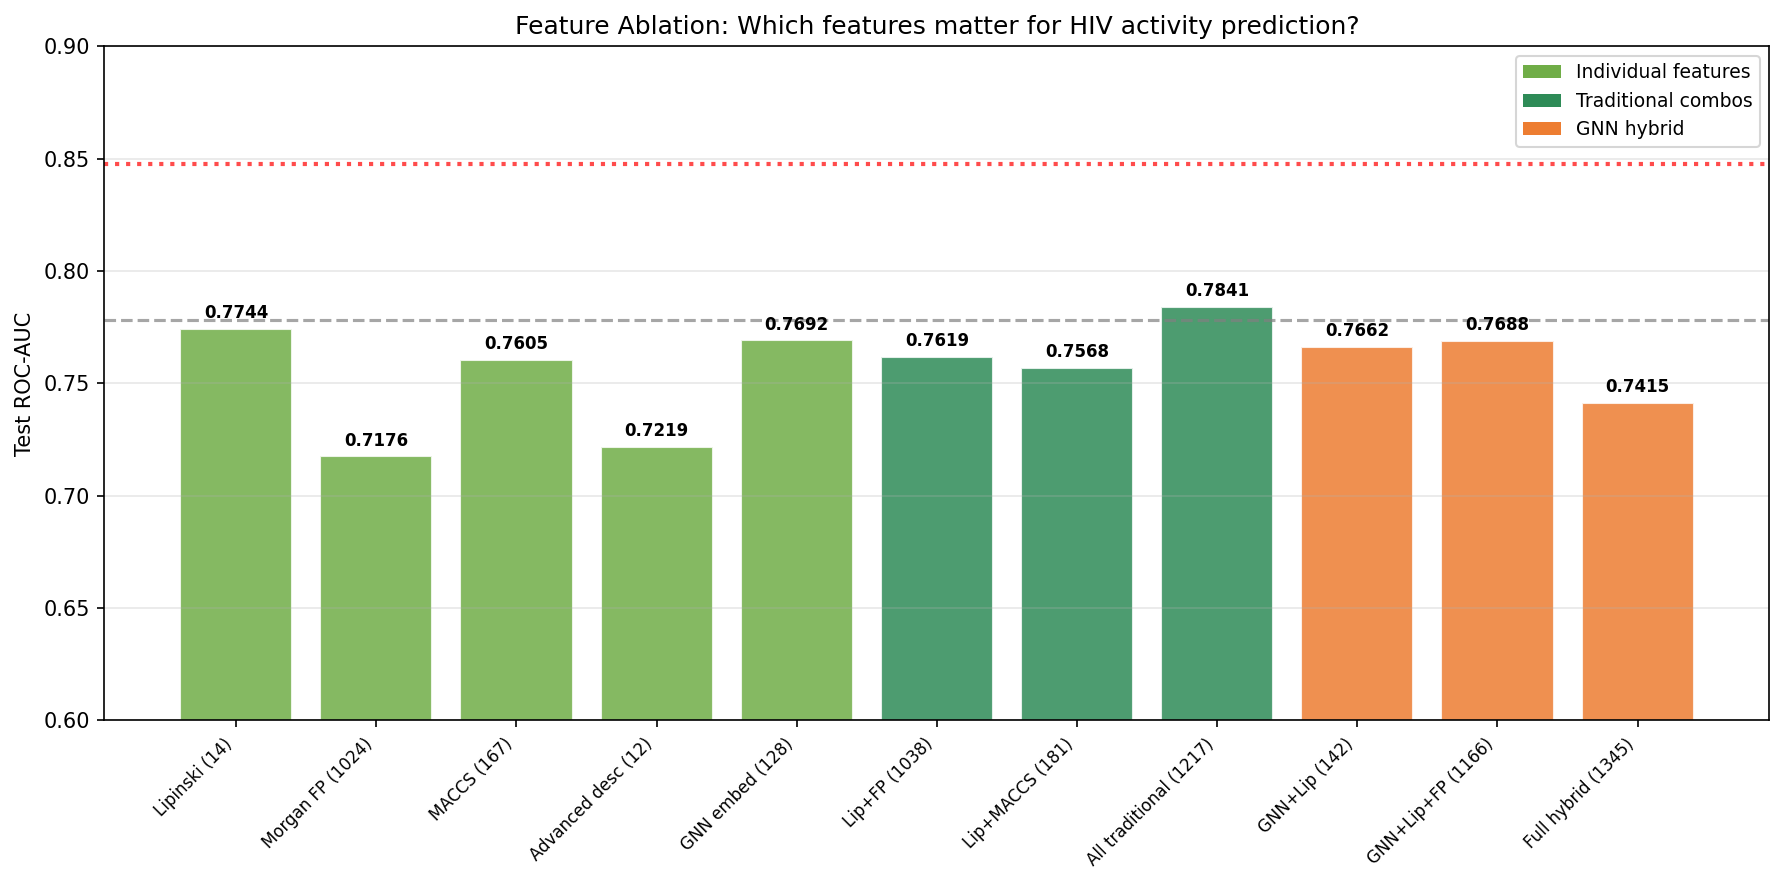

In [2]:
display(Image(filename='../results/phase3_ablation.png', width=800))

## Master Comparison: All Phases

| Rank | Model | Test AUC | Phase | Type |
|------|-------|----------|-------|------|
| — | SOTA (DeeperGCN+VN) | 0.8476 | — | Published |
| **1** | **GIN+Edge (no VN)** | **0.7860** | **3** | **GNN** |
| 2 | All traditional (1217) | 0.7841 | 3 | Feature→CB |
| 3 | CatBoost (Mark) | 0.7782 | 1 | Feature→CB |
| 4 | Lipinski (14) | 0.7744 | 3 | Feature→CB |
| 5 | RF+Combined | 0.7707 | 1 | Feature→RF |
| 6 | GNN embed→CB | 0.7692 | 3 | Hybrid |
| 7 | GNN+Lip+FP→CB | 0.7688 | 3 | Hybrid |
| 8 | MLP-Domain9 (Mark) | 0.7670 | 2 | Neural |
| 9 | GIN+Edge+VN | 0.7622 | 3 | GNN |
| 10 | Phase 2 GIN (raw) | 0.7053 | 2 | GNN |

Gap to SOTA closed from **0.073** (Phase 1) to **0.062** (Phase 3).

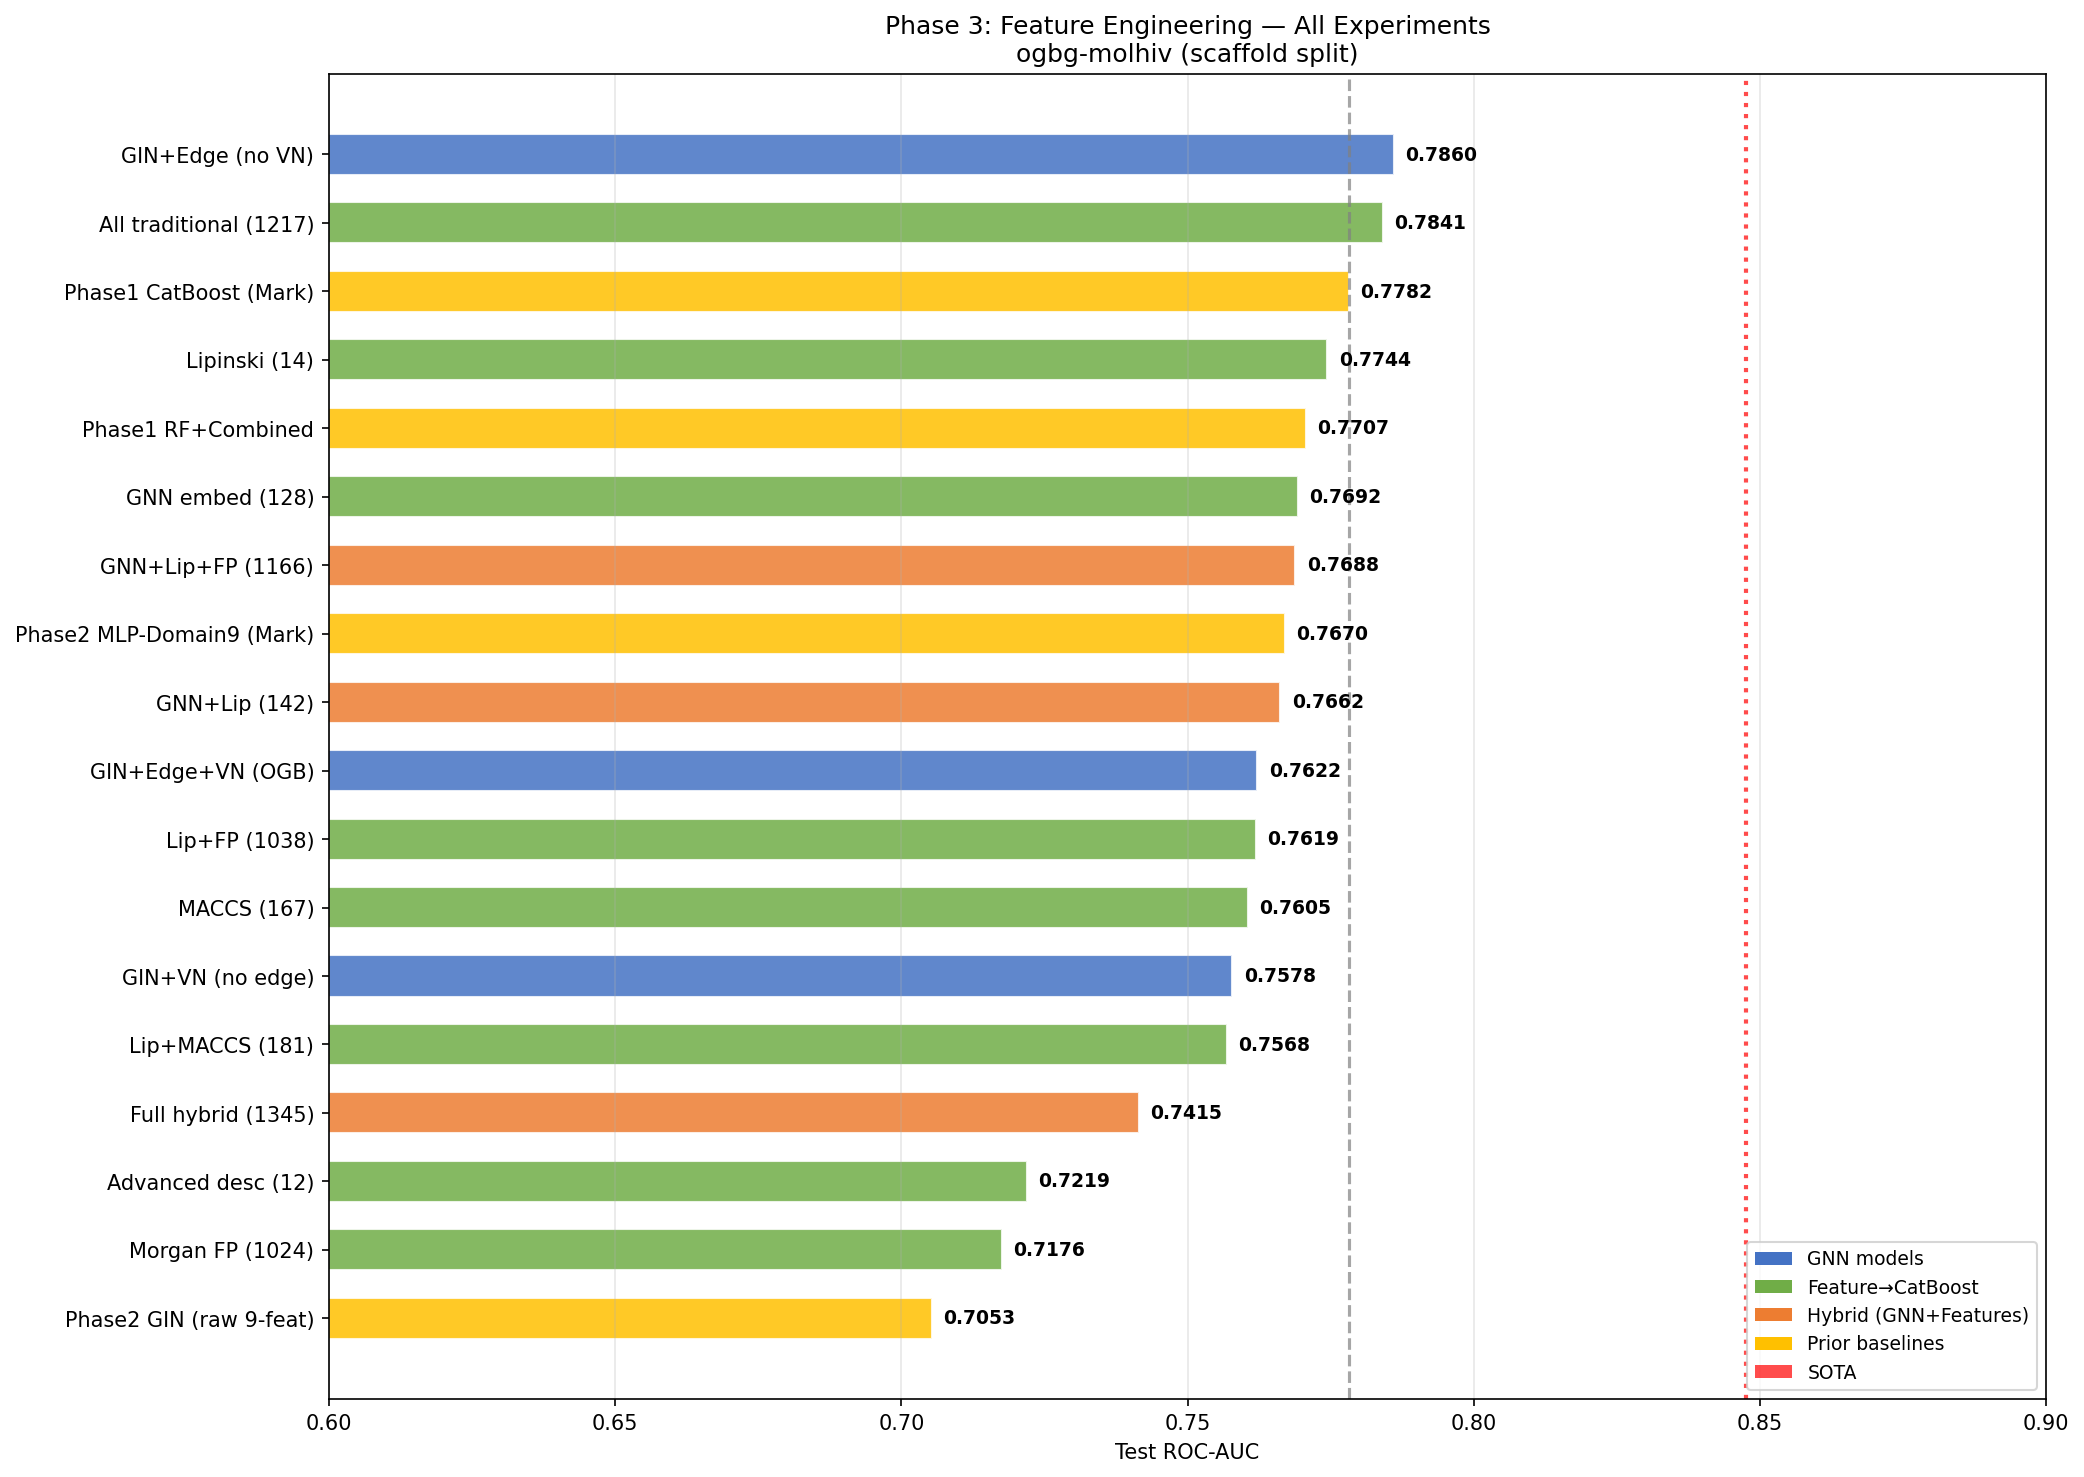

In [3]:
display(Image(filename='../results/phase3_model_comparison.png', width=900))

## Conclusions & Next Steps

### Phase 3 Headline Findings

1. **Edge features are the #1 lever**: +0.081 AUC from 3 bond features > any model architecture change
2. **Virtual node overfits on scaffold split**: +0.03 val AUC but -0.024 test AUC — a generalization trap
3. **More features can HURT**: Full hybrid (1345d) < Lipinski alone (14d) by 0.033 AUC
4. **GIN+Edge is the new champion (0.7860)**: First GNN to beat CatBoost, gap to SOTA now 0.062

### The Bottleneck Is Now Model Architecture, Not Features

Phase 1-2 bottleneck was features (edge features missing). Now that edge features are properly encoded, the remaining 0.062 gap to SOTA (DeeperGCN+VN at 0.8476) likely requires:
- Deeper architecture (5+ layers with JK connections)
- Better pooling (attention-based instead of sum/mean)
- AUC-margin loss (as in DeepAUC paper, +0.02 improvement reported)
- Possibly a larger hidden dimension (256 or 512) with proper regularization

### Post-Worthy Finding
> "Adding 3 bond features to my GNN boosted HIV drug prediction by +0.081 AUC — bigger than switching from LogReg to CatBoost. Meanwhile, throwing ALL features (1345 dims) at CatBoost actually made it WORSE. In molecular ML, knowing WHICH features matter beats having MORE features."
